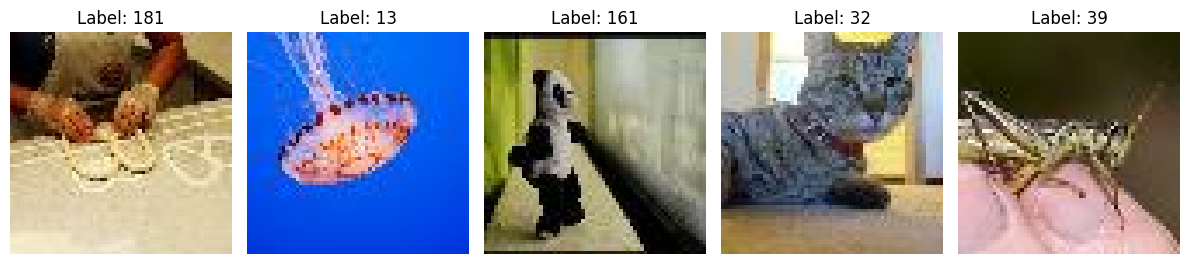

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = load_dataset("slegroux/tiny-imagenet-200-clean")

train_dataset = dataset["train"].train_test_split(test_size=0.05, stratify_by_column="label")["test"]
val_dataset   = dataset["validation"]
test_dataset  = dataset["test"]

plt.figure(figsize=(12, 6))
for i in range(5):
    img = train_dataset[i]["image"]
    label = train_dataset[i]["label"]

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np

orb = cv2.ORB_create()

def preprocess_orb(pil_img):
    return np.array(pil_img.convert("L"))


In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch.optim as optim

class TinyDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        img = self.dataset[idx]["image"]
        return self.transform(img)

ae_transform = T.Compose([T.Resize((32,32)), T.ToTensor()])

class SmallAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(16*8*8, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16*8*8),
            nn.Unflatten(1, (16,8,8)),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
    def forward(self,x):
        z = self.encoder(x)
        return self.decoder(z)

autoencoder = SmallAutoencoder(latent_dim=64).to(device)

def train_autoencoder(model, dataset, epochs=2, batch_size=64):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in loader:
            batch = batch.to(device)
            opt.zero_grad()
            recon = model(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        print(f"AE epoch {epoch+1}: {total_loss/len(loader):.4f}")
    model.eval()

ae_dataset = TinyDataset(train_dataset, transform=ae_transform)
train_autoencoder(autoencoder, ae_dataset, epochs=10, batch_size=128)

AE epoch 1: 0.0660
AE epoch 2: 0.0489
AE epoch 3: 0.0353
AE epoch 4: 0.0294
AE epoch 5: 0.0260
AE epoch 6: 0.0236
AE epoch 7: 0.0221
AE epoch 8: 0.0210
AE epoch 9: 0.0201
AE epoch 10: 0.0194


In [ ]:
from tqdm import tqdm

def get_orb_embeddings(images):
    embs = []
    for img in tqdm(images, desc="ORB embeddings"):
        gray = preprocess_orb(img)
        kps, desc = orb.detectAndCompute(gray, None)
        if desc is None or len(desc)==0:
            vec = np.zeros(64, dtype=np.float32)
        else:
            bits = np.unpackbits(desc[:, :8], axis=1)
            vec = bits.mean(axis=0).astype(np.float32)
        vec = vec / (np.linalg.norm(vec) + 1e-8)
        embs.append(torch.tensor(vec, device=device))
    return embs

def get_ae_embeddings(images, batch_size=256):
    embs = []
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = [ae_transform(img) for img in images[i:i+batch_size]]
            batch_tensor = torch.stack(batch).to(device)
            z = autoencoder.encoder(batch_tensor)
            z_norm = z / (z.norm(dim=1, keepdim=True)+1e-8)
            for row in z_norm:
                embs.append(row)
    return embs

train_images = [dp["image"] for dp in train_dataset]
train_labels = [dp["label"] for dp in train_dataset]

orb_embeds  = get_orb_embeddings(train_images)
ae_embeds   = get_ae_embeddings(train_images, batch_size=128)

ORB embeddings: 100%|██████████| 4909/4909 [00:03<00:00, 1422.58it/s]


In [ ]:
def evaluate(model, loader, threshold=0.5):
    tp=tn=fp=fn=0
    model.eval()
    for a,b,label in loader:
        with torch.no_grad():
            pred = (model(a,b) > threshold).long().squeeze()
        tp += ((pred==1)&(label==1)).sum()
        tn += ((pred==0)&(label==0)).sum()
        fp += ((pred==1)&(label==0)).sum()
        fn += ((pred==0)&(label==1)).sum()
    acc = (tp+tn).item()/(tp+tn+fp+fn).item()
    prec = tp.item()/(tp+fp).item() if (tp+fp)>0 else 0
    rec  = tp.item()/(tp+fn).item() if (tp+fn)>0 else 0
    return acc, prec, rec

In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random

class SimpleSiamese(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim*2, 256),
            nn.ReLU(),
            nn.Linear(256,1),
            nn.Sigmoid()
        )
    def forward(self,a,b):
        return self.fc(torch.cat([a,b],dim=1))

class PairDataset(Dataset):
    def __init__(self, embs, labels):
        self.embs = embs
        self.labels = labels
        self.by_label = {}
        for e,l in zip(embs, labels):
            self.by_label.setdefault(l, []).append(e)
        self.label_keys = list(self.by_label.keys())
    def __len__(self):
        return 20000
    def __getitem__(self, idx):
        if random.random() < 0.5:
            # positive
            c = random.choice(self.label_keys)
            a,b = random.sample(self.by_label[c], 2)
            return a,b,torch.tensor(1.0, device=device)
        else:
            c1,c2 = random.sample(self.label_keys,2)
            a = random.choice(self.by_label[c1])
            b = random.choice(self.by_label[c2])
            return a,b,torch.tensor(0.0, device=device)

def train_siamese(embs, labels, epochs=10, lr=1e-4):
    ds = PairDataset(embs, labels)
    loader = DataLoader(ds, batch_size=64, shuffle=True)
    model = SimpleSiamese(embs[0].shape[0]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for ep in range(epochs):
        for a,b,label in loader:
            opt.zero_grad()
            pred = model(a,b)
            loss = loss_fn(pred.squeeze(), label)
            loss.backward()
            opt.step()
        print(f"Siamese epoch {ep+1} done")
    return model


In [ ]:
class EvalPairDataset(Dataset):
    def __init__(self, embs, labels):
        self.embs = embs
        self.labels = labels
        self.pos_pairs = []
        by_label = {}
        for idx,l in enumerate(labels):
            by_label.setdefault(l, []).append(idx)
        for l,idxs in by_label.items():
            if len(idxs) > 1:
                for i in range(len(idxs)-1):
                    self.pos_pairs.append((idxs[i], idxs[i+1]))
        self.neg_pairs = []
        keys = list(by_label.keys())
        import random
        for i in range(len(self.pos_pairs)):
            l1,l2 = random.sample(keys,2)
            self.neg_pairs.append((by_label[l1][0], by_label[l2][0]))
        self.pairs = self.pos_pairs + self.neg_pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        i1,i2 = self.pairs[idx]
        label = 1 if idx < len(self.pos_pairs) else 0
        return self.embs[i1], self.embs[i2], torch.tensor(label, device=device)


In [ ]:
test_images = [dp["image"] for dp in test_dataset]
test_labels = [dp["label"] for dp in test_dataset]

orb_test   = get_orb_embeddings(test_images)
ae_test    = get_ae_embeddings(test_images, batch_size=128)

orb_model = train_siamese(orb_embeds, train_labels, epochs=5, lr=1e-4)
ae_model  = train_siamese(ae_embeds, train_labels, epochs=5, lr=1e-4)

orb_eval_ds = EvalPairDataset(orb_test, test_labels)
ae_eval_ds  = EvalPairDataset(ae_test, test_labels)

orb_loader = DataLoader(orb_eval_ds, batch_size=256, shuffle=False)
ae_loader  = DataLoader(ae_eval_ds, batch_size=256, shuffle=False)

orb_acc, orb_prec, orb_rec = evaluate(orb_model, orb_loader)
ae_acc,  ae_prec,  ae_rec  = evaluate(ae_model, ae_loader)

print("ORB: ", orb_acc, orb_prec, orb_rec)
print("AE:  ", ae_acc, ae_prec, ae_rec)


ORB embeddings: 100%|██████████| 4923/4923 [00:03<00:00, 1631.58it/s]


Siamese epoch 1 done
Siamese epoch 2 done
Siamese epoch 3 done
Siamese epoch 4 done
Siamese epoch 5 done
Siamese epoch 1 done
Siamese epoch 2 done
Siamese epoch 3 done
Siamese epoch 4 done
Siamese epoch 5 done
ORB:  0.5007410544145671 0.5004884856943476 0.7592631801820876
AE:   0.5158797374550074 0.5170532060027285 0.4814736396358247


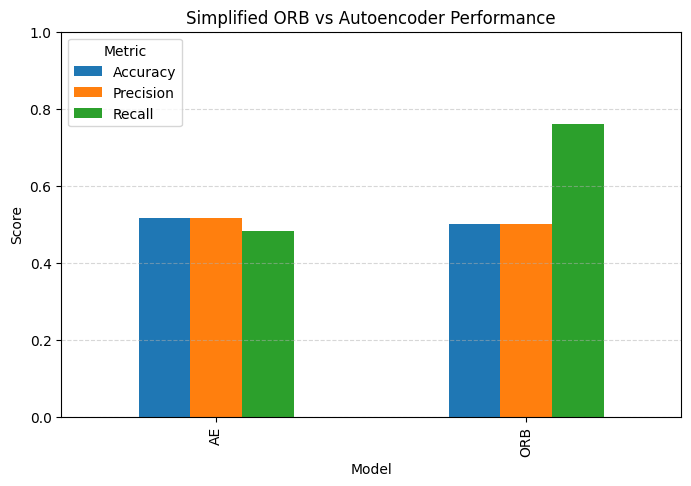

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Model": ["ORB", "ORB", "ORB", "AE", "AE", "AE"],
    "Metric": ["Accuracy", "Precision", "Recall", "Accuracy", "Precision", "Recall"],
    "Score": [orb_acc, orb_prec, orb_rec, ae_acc, ae_prec, ae_rec]
})
pivot = df.pivot(index="Model", columns="Metric", values="Score")
ax = pivot.plot(kind="bar", figsize=(8,5))
ax.set_ylim(0,1)
plt.title("Simplified ORB vs Autoencoder Performance")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

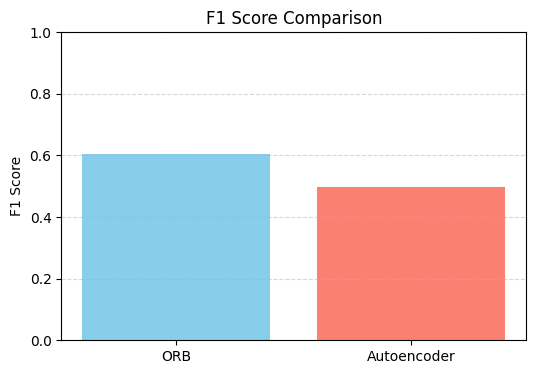

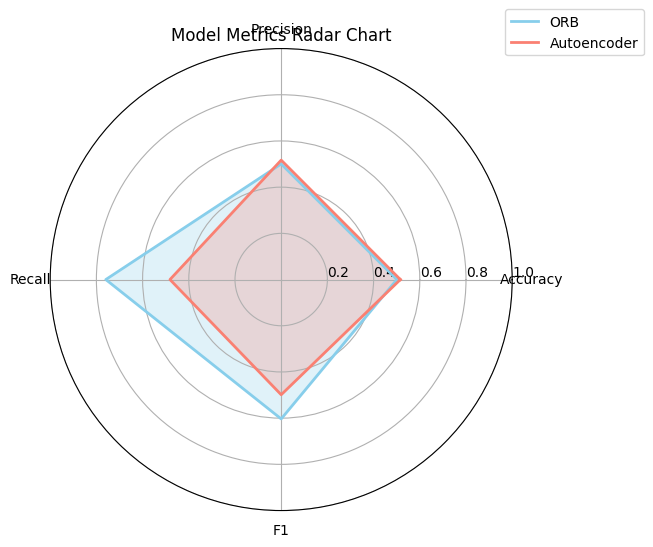

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

orb_f1 = 2 * orb_prec * orb_rec / (orb_prec + orb_rec + 1e-8)
ae_f1  = 2 * ae_prec * ae_rec / (ae_prec + ae_rec + 1e-8)

models = ['ORB', 'Autoencoder']
f1_scores = [orb_f1, ae_f1]
plt.figure(figsize=(6, 4))
plt.bar(models, f1_scores, color=['skyblue', 'salmon'])
plt.ylim(0, 1)
plt.title('F1 Score Comparison')
plt.ylabel('F1 Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
orb_values = [orb_acc, orb_prec, orb_rec, orb_f1]
ae_values  = [ae_acc, ae_prec, ae_rec, ae_f1]
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

orb_plot = orb_values + orb_values[:1]
ae_plot  = ae_values + ae_values[:1]

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_rlabel_position(0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'])
ax.set_ylim(0, 1)
ax.plot(angles, orb_plot, label='ORB', color='skyblue', linewidth=2)
ax.fill(angles, orb_plot, color='skyblue', alpha=0.25)
ax.plot(angles, ae_plot, label='Autoencoder', color='salmon', linewidth=2)
ax.fill(angles, ae_plot, color='salmon', alpha=0.25)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Model Metrics Radar Chart')
plt.show()


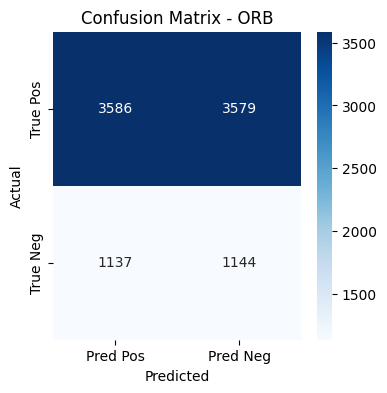

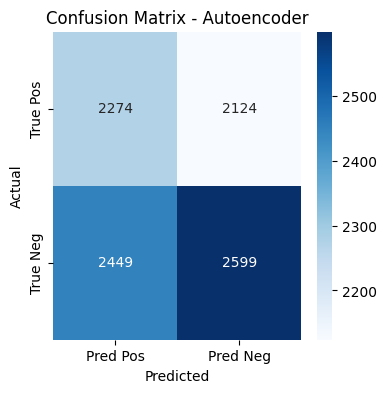

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def confusion_counts(model, loader, threshold=0.5):
    tp = tn = fp = fn = 0
    model.eval()
    for a, b, label in loader:
        with torch.no_grad():
            prob = model(a, b).squeeze()
        pred = (prob > threshold).long()
        tp += ((pred == 1) & (label == 1)).sum().item()
        tn += ((pred == 0) & (label == 0)).sum().item()
        fp += ((pred == 1) & (label == 0)).sum().item()
        fn += ((pred == 0) & (label == 1)).sum().item()
    return tp, tn, fp, fn

def plot_confusion_matrix(tp, tn, fp, fn, model_name):
    cm = np.array([[tp, fp], [fn, tn]])
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Pos','Pred Neg'],
                yticklabels=['True Pos','True Neg'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

orb_tp, orb_tn, orb_fp, orb_fn = confusion_counts(orb_model, orb_loader)
ae_tp, ae_tn, ae_fp, ae_fn = confusion_counts(ae_model, ae_loader)

plot_confusion_matrix(orb_tp, orb_tn, orb_fp, orb_fn, 'ORB')
plot_confusion_matrix(ae_tp, ae_tn, ae_fp, ae_fn, 'Autoencoder')


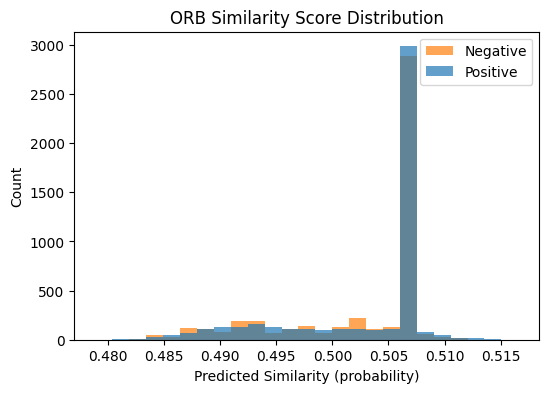

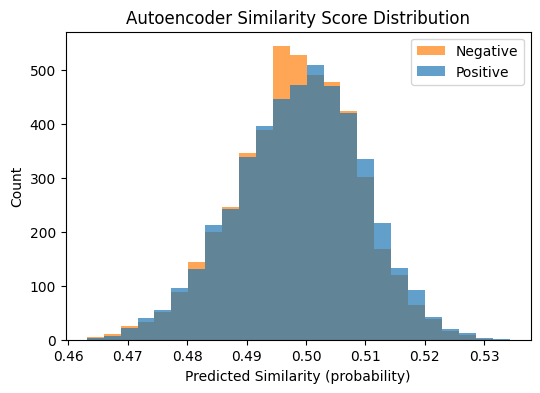

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_scores_and_labels(model, loader):
    scores = []
    labels = []
    model.eval()
    for a, b, label in loader:
        with torch.no_grad():
            prob = model(a, b).squeeze()
        scores.extend(prob.cpu().numpy())
        labels.extend(label.cpu().numpy())
    return np.array(scores), np.array(labels)

orb_scores, orb_labels = get_scores_and_labels(orb_model, orb_loader)
ae_scores, ae_labels   = get_scores_and_labels(ae_model, ae_loader)

def plot_score_distribution(scores, labels, model_name):
    plt.figure(figsize=(6, 4))
    plt.hist([scores[labels == 1], scores[labels == 0]],
             bins=25, alpha=0.7, label=['Positive', 'Negative'],
             histtype='stepfilled')
    plt.title(f'{model_name} Similarity Score Distribution')
    plt.xlabel('Predicted Similarity (probability)')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

plot_score_distribution(orb_scores, orb_labels, 'ORB')
plot_score_distribution(ae_scores, ae_labels, 'Autoencoder')
